In [29]:
import pandas as pd
import numpy as np
from lobster import *

In [ ]:
message_path  = "data/LOBSTER_SampleFile_INTC_2012-06-21_5/INTC_2012-06-21_34200000_57600000_message_5.csv"
orderbook_path = "data/LOBSTER_SampleFile_INTC_2012-06-21_5/INTC_2012-06-21_34200000_57600000_orderbook_5.csv"
levels=5
K=5

msg, ob, qr, df = load_lobster_data(message_path, orderbook_path, levels=levels, K=K)
df

,time,delta_time,type,price,lvl,size,pref,P_1,Q_1,P_-1,...,P_-3,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5
0,34200.006241,0.006241,L,275200,1,100,275150.0,275200.0,166,275100.0,...,274900.0,200,275500.0,0,274800.0,661,275600.0,100,274700.0,300
1,34200.006462,0.000221,L,275500,4,100,275150.0,275200.0,166,275100.0,...,274900.0,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300
2,34200.048864,0.042402,C,275000,-2,100,275150.0,275200.0,166,275100.0,...,274900.0,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300
3,34200.048883,0.000020,C,275100,-1,100,275150.0,275200.0,166,275100.0,...,274900.0,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300
4,34200.048989,0.000106,L,275000,-2,100,275150.0,275200.0,166,275100.0,...,274900.0,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580346,57599.860444,0.011408,C,267200,1,34600,267150.0,267200.0,88104,267100.0,...,266900.0,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174
580347,57599.860635,0.000191,L,267000,-2,16600,267150.0,267200.0,88104,267100.0,...,266900.0,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174
580348,57599.870108,0.009473,C,267400,3,600,267150.0,267200.0,88104,267100.0,...,266900.0,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174
580349,57599.939645,0.069536,L,267200,1,100,267150.0,267200.0,88204,267100.0,...,266900.0,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174


In [31]:
table1 = make_descriptive_table(df, K=5)
table1

,#L (×10^3),#C (×10^3),#M (×10^2),AES,AIT (ms)
Level,,,,,
1,197.19,162.42,324.82,483.88,32.5
2,40.20,59.75,0.00,441.55,45.6
3,22.71,22.55,0.00,451.23,71.5
4,13.23,11.88,0.00,475.07,67.4
5,9.50,8.44,0.00,596.93,65.6


In [32]:
aes = compute_aes_by_level(df, K=5, lvl_col="lvl", size_col="size") 
df_norm = normalize_by_aes(df, aes=aes, K=5)
df_norm.head()

,time,delta_time,type,price,lvl,size,pref,P_1,Q_1,P_-1,...,P_-3,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5
0,34200.006241,0.006241,L,275200,1,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1
1,34200.006462,0.000221,L,275500,4,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
2,34200.048864,0.042402,C,275000,-2,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
3,34200.048883,0.000020,C,275100,-1,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
4,34200.048989,0.000106,L,275000,-2,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1


### Training DataFrame: ###
From where we will extract our different state vectors $x_k$.

In [33]:
event_map = {"L": 0, "C": 1, "M": 2}

df_train = df_norm.copy()

# 1) event id
df_train["event_id"] = df_train["type"].map(event_map).astype("int64")

# 2) last event id (η_{k-1}) as categorical
df_train["last_event_id"] = df_train["event_id"].shift(1).fillna(0).astype("int64")

# 3) hour hk (categorical). If your time is seconds since midnight.
df_train["hour"] = (df_train["time"] // 3600).astype("int64")

# 4) q_event = queue at the event level ℓ_k
def _q_event_row(row):
    l = int(row["lvl"])
    if l == 0:
        return np.nan
    if l > 0:
        return row[f"Q_{l}"]
    else:
        return row[f"Q_{l}"]  # l is negative -> column name "Q_-1" etc.

df_train["q_event"] = df_train.apply(_q_event_row, axis=1).astype("float64")

# 5) clean rows (lvl=0 or missing q_event / dt)
df_train = df_train.dropna(subset=["q_event", "delta_time"]).reset_index(drop=True)

# Optional: keep only what you need for training
df_train = df_train[["q_event", "hour", "last_event_id", "event_id", "delta_time"]].copy()
df_train.head()

,q_event,hour,last_event_id,event_id,delta_time
0,1.0,9,0,0,0.006241
1,1.0,9,0,0,0.000221
2,0.0,9,0,1,0.042402
3,1.0,9,1,1,0.000020
4,1.0,9,1,0,0.000106


In [38]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ----------------------------
# 0) Reproducibility + device
# ----------------------------
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)

device: mps


In [39]:
# ----------------------------
# 1) Torch dataset
# ----------------------------
class DQRDataset(Dataset):
    """
    Provides batches of (q, hour, last_event, y, dt).
    We always return hour & last_event even if a given model doesn't use them,
    so the training loop stays simple.
    """
    def __init__(self, q, hour, last_event, y, dt):
        self.q = torch.tensor(q, dtype=torch.float32)                 # (N,1)
        self.hour = torch.tensor(hour, dtype=torch.long)              # (N,)
        self.last_event = torch.tensor(last_event, dtype=torch.long)  # (N,)
        self.y = torch.tensor(y, dtype=torch.long)                    # (N,)
        self.dt = torch.tensor(dt, dtype=torch.float32)               # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.q[i], self.hour[i], self.last_event[i], self.y[i], self.dt[i]

In [40]:
# ----------------------------
# 2) DQR network (paper 3.3)
# ----------------------------
class DQRNet(nn.Module):
    """
    Implements the MLP described in §3.3:
        Dense(128) + tanh + BatchNorm
        Dense(32)  + tanh + BatchNorm
        Dense(3)   + ReLU   (intensities λ_L, λ_C, λ_M >= 0)

    Categorical features (hour, last_event) are encoded with embeddings of dim=2
    (paper uses embeddings of size 2).
    """
    def __init__(
        self,
        use_hour: bool,
        use_last_event: bool,
        n_hours: int,
        n_last_event: int = 3,
        emb_dim: int = 2,
        hidden=(128, 32),
    ):
        super().__init__()
        self.use_hour = use_hour
        self.use_last_event = use_last_event
        
        # ---- Embeddings (categorical inputs) ----
        # hour embedding: size (n_hours, emb_dim)
        # last_event embedding: size (3, emb_dim)
        self.hour_emb = nn.Embedding(n_hours, emb_dim) if use_hour else None
        self.last_emb = nn.Embedding(n_last_event, emb_dim) if use_last_event else None
        
        # ---- Compute input dim: q_event is always present (1 numeric) ----
        in_dim = 1
        if use_hour:
            in_dim += emb_dim
        if use_last_event:
            in_dim += emb_dim
        
        # ---- MLP trunk ----
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden[0]),
            nn.Tanh(),
            nn.BatchNorm1d(hidden[0]),
            nn.Linear(hidden[0], hidden[1]),
            nn.Tanh(),
            nn.BatchNorm1d(hidden[1]),
            nn.Linear(hidden[1], 3),
            nn.ReLU(),  # ensures positive intensities
        )
        
    def forward(self, q, hour=None, last_event=None):
        """
        q: (B,1) float
        hour: (B,) long (optional)
        last_event: (B,) long (optional)
        returns lambdas: (B,3) positive
        """
        feats = [q]
        if self.use_hour:
            feats.append(self.hour_emb(hour))
        if self.use_last_event:
            feats.append(self.last_emb(last_event))
        x = torch.cat(feats, dim=1)
        return self.net(x)

In [41]:
# ----------------------------
# 3) DQR loss (paper NLL)
# ----------------------------
def dqr_nll(lambdas, y, dt):
    """
    Negative log-likelihood per event:
      loss_k = Λ(x_k) * Δt_k - log λ_{y_k}(x_k)
    where Λ = sum over event types (L,C,M).

    lambdas: (B,3) >= 0
    y: (B,) in {0,1,2}
    dt: (B,) > 0
    """
    Lambda = lambdas.sum(dim=1)                               # (B,)
    lam_y = lambdas[torch.arange(len(y), device=y.device), y] # (B,)
    return (Lambda * dt - torch.log(lam_y + 1e-12)).mean()

### Training / Target vectors: ###

Vanilla : $x_k = [q_k]$

Hours: $x_k = [q_k, h_k]$

Last Event: $x_k = [q_k, \eta_{k-1}]$

Hours + Last Event: $x_k = [q_k, h_k, \eta_{k-1}]$

In [48]:
# ----------------------------
# 4) Prepare numpy arrays from df_train
# ----------------------------
# Expected columns in df_train: q_event, hour, last_event_id, event_id, delta_time
q_np = df_train["q_event"].to_numpy(np.float32).reshape(-1, 1)
h_np = df_train["hour"].to_numpy(np.int64)
le_np = df_train["last_event_id"].to_numpy(np.int64)
y_np = df_train["event_id"].to_numpy(np.int64)
dt_np = df_train["delta_time"].to_numpy(np.float32)

# cardinalities for embeddings
n_hours = int(df_train["hour"].max() - df_train["hour"].min() + 1)   # 15h - 9h + 1h for diff
n_last = 3

In [50]:
# ----------------------------
# 5) Train/val split
# ----------------------------
N = len(y_np)
idx = np.arange(N)
np.random.shuffle(idx)

n_train = int(0.8 * N)
train_idx, val_idx = idx[:n_train], idx[n_train:]

train_ds = DQRDataset(q_np[train_idx], h_np[train_idx], le_np[train_idx], y_np[train_idx], dt_np[train_idx])
val_ds   = DQRDataset(q_np[val_idx],   h_np[val_idx],   le_np[val_idx],   y_np[val_idx],   dt_np[val_idx])

# Batch size: paper uses large batches; pick something safe for your RAM/GPU
BATCH = 4096
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)

In [51]:
# ----------------------------
# 6) Generic training routine
# ----------------------------
def fit_dqr_model(use_hour: bool, use_last_event: bool, max_epochs=200):
    """
    Training setup aligned with paper §3.3:
        - Adam optimizer
        - cyclic learning rate between 1e-5 and 1e-3
        - early stopping patience 10 (stop after 10 epochs without val improvement)
    """
    model = DQRNet(
        use_hour=use_hour,
        use_last_event=use_last_event,
        n_hours=n_hours,
        n_last_event=n_last,
        emb_dim=2,
        hidden=(128, 32),
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=1e-4)

    # CyclicLR: base_lr -> max_lr (paper)
    sched = torch.optim.lr_scheduler.CyclicLR(
        opt,
        base_lr=1e-5,
        max_lr=1e-3,
        step_size_up=2 * len(train_loader),   # heuristic: ~2 epochs up
        cycle_momentum=False,
    )

    best_val = float("inf")
    best_state = None
    patience = 10
    patience_left = patience

    for epoch in range(1, max_epochs + 1):
        # ---- train ----
        model.train()
        tr = 0.0
        for qb, hb, leb, yb, dtb in train_loader:
            qb = qb.to(device)
            hb = hb.to(device)
            leb = leb.to(device)
            yb = yb.to(device)
            dtb = dtb.to(device)

            opt.zero_grad()

            # build forward depending on chosen state x_k
            lam = model(
                qb,
                hour=hb if use_hour else None,
                last_event=leb if use_last_event else None,
            )

            loss = dqr_nll(lam, yb, dtb)
            loss.backward()
            opt.step()
            sched.step()

            tr += loss.item()

        tr /= len(train_loader)

        # ---- validate ----
        model.eval()
        va = 0.0
        with torch.no_grad():
            for qb, hb, leb, yb, dtb in val_loader:
                qb = qb.to(device)
                hb = hb.to(device)
                leb = leb.to(device)
                yb = yb.to(device)
                dtb = dtb.to(device)

                lam = model(
                    qb,
                    hour=hb if use_hour else None,
                    last_event=leb if use_last_event else None,
                )

                va += dqr_nll(lam, yb, dtb).item()

        va /= len(val_loader)

        print(f"epoch {epoch:03d} | train_nll={tr:.6f} | val_nll={va:.6f}")

        # ---- early stopping ----
        if va < best_val - 1e-6:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("early stop")
                break

    model.load_state_dict(best_state)
    model.eval()
    return model

In [52]:
# ----------------------------
# 7) Train the 4 models from §3.4
# ----------------------------
# Vanilla: x_k = [q_k]
model_vanilla = fit_dqr_model(use_hour=False, use_last_event=False)

# Hour: x_k = [q_k, h_k]
model_hour = fit_dqr_model(use_hour=True, use_last_event=False)

# Last event: x_k = [q_k, η_{k-1}]
model_last = fit_dqr_model(use_hour=False, use_last_event=True)

# Hour + last event: x_k = [q_k, h_k, η_{k-1}]
model_full = fit_dqr_model(use_hour=True, use_last_event=True)

epoch 001 | train_nll=12.627684 | val_nll=5.778176
epoch 002 | train_nll=4.170916 | val_nll=3.442205
epoch 003 | train_nll=3.379427 | val_nll=3.141029
epoch 004 | train_nll=3.235771 | val_nll=3.224339
epoch 005 | train_nll=3.138954 | val_nll=2.913216
epoch 006 | train_nll=2.804431 | val_nll=2.659397
epoch 007 | train_nll=2.607253 | val_nll=2.533468
epoch 008 | train_nll=2.517662 | val_nll=2.496479
epoch 009 | train_nll=2.457513 | val_nll=2.351167
epoch 010 | train_nll=2.209918 | val_nll=1.958232
epoch 011 | train_nll=1.885714 | val_nll=1.747252
epoch 012 | train_nll=1.725488 | val_nll=1.696615
epoch 013 | train_nll=1.681459 | val_nll=1.649912
epoch 014 | train_nll=1.620481 | val_nll=1.582716
epoch 015 | train_nll=1.509975 | val_nll=1.428271
epoch 016 | train_nll=1.416416 | val_nll=1.408988
epoch 017 | train_nll=1.395853 | val_nll=1.381626
epoch 018 | train_nll=1.336247 | val_nll=1.278882
epoch 019 | train_nll=1.244703 | val_nll=1.198139
epoch 020 | train_nll=1.189581 | val_nll=1.177581

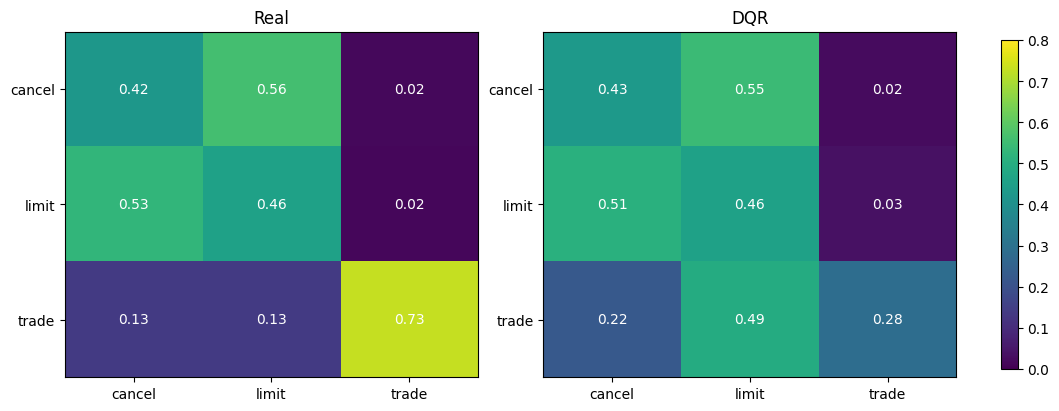

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Transition matrices
# -----------------------------
def transition_matrix_from_sequence(seq: np.ndarray, n: int = 3) -> np.ndarray:
    M = np.zeros((n, n), dtype=np.float64)
    for a, b in zip(seq[:-1], seq[1:]):
        if 0 <= a < n and 0 <= b < n:
            M[a, b] += 1.0
    M = M / (M.sum(axis=1, keepdims=True) + 1e-12)
    return M

# Real transitions from your dataset
seq_real = df_train["event_id"].to_numpy(np.int64)  # or df["event_id"] if you kept it there
M_real = transition_matrix_from_sequence(seq_real, n=3)

# DQR simulated transitions
@torch.no_grad()
def simulate_event_types_only(model, n_steps=200_000, q0=None, last0=0):
    model.eval()

    if q0 is None:
        q0 = float(np.random.choice(df_train["q_event"].to_numpy()))
    q_curr = q0
    last = int(last0)

    etas = np.empty(n_steps, dtype=np.int64)

    for k in range(n_steps):
        q_t  = torch.tensor([[q_curr]], dtype=torch.float32, device=device)
        le_t = torch.tensor([last], dtype=torch.long, device=device)

        lam = model(q_t, hour=None, last_event=le_t).flatten().detach().cpu().numpy()

        # birth-death boundary: no departures if empty
        if q_curr <= 0.0:
            lam[1] = 0.0  # cancel
            lam[2] = 0.0  # trade

        Lam = lam.sum()
        if Lam <= 0.0:
            eta = 0
        else:
            eta = int(np.random.choice(3, p=lam / Lam))

        etas[k] = eta

        # queue update (minimal, enough for transition matrix)
        if eta == 0:      # limit
            q_curr += 1.0
        else:             # cancel or trade
            q_curr = max(q_curr - 1.0, 0.0)

        last = eta

    return etas

# IMPORTANT: ensure the mapping matches your labels order.
# If your event_map was {"L":0,"C":1,"M":2}, then labels below are ["limit","cancel","trade"].
# For the paper-style order ["cancel","limit","trade"], reorder matrices afterwards (see below).

seq_dqr = simulate_event_types_only(model_last, n_steps=200_000, q0=None, last0=0)
M_dqr = transition_matrix_from_sequence(seq_dqr, n=3)

# -----------------------------
# 2) Reorder to match paper labels: [cancel, limit, trade]
# If your internal order is [limit, cancel, trade] (L,C,M) = (0,1,2),
# then permute indices with p = [1,0,2].
# If your internal order is already [cancel, limit, trade], set p = [0,1,2].
# -----------------------------
p = [1, 0, 2]  # <-- change to [0,1,2] if your event_id is already (cancel,limit,trade)

M_real_p = M_real[np.ix_(p, p)]
M_dqr_p  = M_dqr[np.ix_(p, p)]

labels = ["cancel", "limit", "trade"]

# -----------------------------
# 3) Plot side-by-side (Real vs DQR)
# -----------------------------
def plot_two_transition_mats(M_left, M_right, labels, titles=("Real", "DQR"),
                             vmin=0.0, vmax=0.8, fmt="{:.2f}"):
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), constrained_layout=True)

    for ax, M, title in zip(axes, [M_left, M_right], titles):
        im = ax.imshow(M, vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels)
        ax.set_title(title)

        # annotations
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                ax.text(j, i, fmt.format(M[i, j]), ha="center", va="center", color="white")

    # single shared colorbar (matches the style in your screenshot)
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.95)
    return fig

fig = plot_two_transition_mats(M_real_p, M_dqr_p, labels, titles=("Real", "DQR"), vmin=0.0, vmax=0.8)
plt.show()